# Supervised Learning & Optimization: Logistic Regression



Environment Setup & Data Ingestion

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

start_time = time.time()
print("[INFO] Fetching Parkinson's Medical Dataset from UCI...")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
df = pd.read_csv(url)

# Separate acoustic features from patient status
X_raw = df.drop(columns=["name", "status"]).values
y = df["status"].values

print("-" * 50)
print(f"Dataset Shape       : {X_raw.shape[0]} samples, {X_raw.shape[1]} features")
print(
    f"Class Breakdown     : {np.sum(y == 1)} Positive (Parkinson's) |"
    f" {np.sum(y == 0)} Negative (Healthy)"
)
print(f"Positive Class Ratio: {np.mean(y == 1) * 100:.2f}%")
print(f"Execution Time      : {time.time() - start_time:.2f} seconds")
print("-" * 50)

[INFO] Fetching Parkinson's Medical Dataset from UCI...
--------------------------------------------------
Dataset Shape       : 195 samples, 22 features
Class Breakdown     : 147 Positive (Parkinson's) | 48 Negative (Healthy)
Positive Class Ratio: 75.38%
Execution Time      : 1.37 seconds
--------------------------------------------------


#Leak-Free Z-Score Scaler (From Scratch)

In [2]:
# 1. Custom Z-Score Scaler preserving train/test isolation
class StandardScalerFromScratch:

  def __init__(self):
    self.mean_ = None
    self.scale_ = None

  def fit(self, X):
    self.mean_ = np.mean(X, axis=0)
    self.scale_ = np.std(X, axis=0) + 1e-9  # Avoid division by zero
    return self

  def transform(self, X):
    return (X - self.mean_) / self.scale_

  def fit_transform(self, X):
    return self.fit(X).transform(X)


# Unit verification test
demo_scaler = StandardScalerFromScratch()
X_demo = demo_scaler.fit_transform(X_raw)
print("[VERIFICATION] StandardScalerFromScratch:")
print(f"Feature Means (Target ~ 0.0) : {np.mean(X_demo):.6f}")
print(
    f"Feature Std Devs (Target ~ 1.0):"
    f" {np.mean(np.std(X_demo, axis=0)):.6f}"
)

[VERIFICATION] StandardScalerFromScratch:
Feature Means (Target ~ 0.0) : 0.000000
Feature Std Devs (Target ~ 1.0): 0.999999


Stratified K-Fold CV Generator (From Scratch)

In [3]:
# 2. Stratified Cross-Validation Splitting Engine
def stratified_k_fold_indices(y, n_splits=5, seed=42):
  np.random.seed(seed)
  folds = [[] for _ in range(n_splits)]

  # Stratify by isolating and shuffling each class separately
  for label in np.unique(y):
    label_indices = np.where(y == label)[0]
    np.random.shuffle(label_indices)
    split_groups = np.array_split(label_indices, n_splits)
    for fold_idx in range(n_splits):
      folds[fold_idx].extend(split_groups[fold_idx])

  splits = []
  all_indices = set(range(len(y)))
  for fold_idx in range(n_splits):
    test_idx = np.array(folds[fold_idx])
    train_idx = np.array(list(all_indices - set(test_idx)))
    splits.append((train_idx, test_idx))

  return splits


# Verification of class distribution balance across folds
cv_splits = stratified_k_fold_indices(y, n_splits=5, seed=42)
print("[VERIFICATION] Stratified 5-Fold Validation Splits:")
for i, (train_idx, test_idx) in enumerate(cv_splits):
  test_pos_ratio = np.mean(y[test_idx] == 1) * 100
  print(
      f"Fold {i+1} -> Train Size: {len(train_idx)} | Test Size:"
      f" {len(test_idx)} | Test Class-1 Ratio: {test_pos_ratio:.1f}%"
  )

[VERIFICATION] Stratified 5-Fold Validation Splits:
Fold 1 -> Train Size: 155 | Test Size: 40 | Test Class-1 Ratio: 75.0%
Fold 2 -> Train Size: 155 | Test Size: 40 | Test Class-1 Ratio: 75.0%
Fold 3 -> Train Size: 156 | Test Size: 39 | Test Class-1 Ratio: 74.4%
Fold 4 -> Train Size: 157 | Test Size: 38 | Test Class-1 Ratio: 76.3%
Fold 5 -> Train Size: 157 | Test Size: 38 | Test Class-1 Ratio: 76.3%


 Logistic Regression & Metric Engine (From Scratch)

In [4]:
# 3. Model Engine & Evaluation Metrics
class LogisticRegressionFromScratch:

  def __init__(self, learning_rate=0.01, iterations=1000, lambda_param=0.1):
    self.lr = learning_rate
    self.iterations = iterations
    self.lambda_param = lambda_param
    self.weights = None
    self.bias = None
    self.cost_history = []

  def _sigmoid(self, z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

  def fit(self, X, y):
    n_samples, n_features = X.shape
    self.weights = np.zeros(n_features)
    self.bias = 0.0
    self.cost_history = []

    for _ in range(self.iterations):
      linear_model = np.dot(X, self.weights) + self.bias
      y_pred = self._sigmoid(linear_model)

      # Analytical Gradients with L2 Penalty
      dw = (1 / n_samples) * np.dot(X.T, (y_pred - y)) + (
          self.lambda_param / n_samples
      ) * self.weights
      db = (1 / n_samples) * np.sum(y_pred - y)

      self.weights -= self.lr * dw
      self.bias -= self.lr * db

      # Binary Cross-Entropy Loss + L2 Regularization
      cost = -(1 / n_samples) * np.sum(
          y * np.log(y_pred + 1e-9) + (1 - y) * np.log(1 - y_pred + 1e-9)
      )
      cost += (self.lambda_param / (2 * n_samples)) * np.sum(
          np.square(self.weights)
      )
      self.cost_history.append(cost)

  def predict_proba(self, X):
    return self._sigmoid(np.dot(X, self.weights) + self.bias)

  def predict(self, X, threshold=0.5):
    return (self.predict_proba(X) >= threshold).astype(int)


def calculate_metrics(y_true, y_pred):
  tp = np.sum((y_true == 1) & (y_pred == 1))
  fp = np.sum((y_true == 0) & (y_pred == 1))
  fn = np.sum((y_true == 1) & (y_pred == 0))

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  f1 = (
      2 * (precision * recall) / (precision + recall)
      if (precision + recall) > 0
      else 0.0
  )
  return precision, recall, f1


print("[INFO] Model Engine and Evaluation Metrics compiled successfully.")

[INFO] Model Engine and Evaluation Metrics compiled successfully.


Leak-Free Grid Search with Stratified Cross-Validation

In [5]:
# 4. Systematic Hyperparameter Search
start_grid_time = time.time()
print(
    "[INFO] Initiating Grid Search (Learning Rate vs L2 Penalty Lambda)...\n"
)

learning_rates = [0.01, 0.1, 0.5]
lambda_params = [0.01, 0.1, 1.0]
grid_f1_scores = []

best_f1 = 0.0
best_params = {}

for lr in learning_rates:
  for lam in lambda_params:
    fold_f1s = []

    for train_idx, test_idx in cv_splits:
      X_train_raw, y_train = X_raw[train_idx], y[train_idx]
      X_test_raw, y_test = X_raw[test_idx], y[test_idx]

      # Transform strictly with parameters from the training fold
      scaler = StandardScalerFromScratch()
      X_train = scaler.fit_transform(X_train_raw)
      X_test = scaler.transform(X_test_raw)

      model = LogisticRegressionFromScratch(
          learning_rate=lr, iterations=500, lambda_param=lam
      )
      model.fit(X_train, y_train)

      y_pred = model.predict(X_test)
      _, _, f1 = calculate_metrics(y_test, y_pred)
      fold_f1s.append(f1)

    avg_f1 = np.mean(fold_f1s)
    grid_f1_scores.append(avg_f1)
    print(f"Hyperparameters: LR={lr:<4} | Lambda={lam:<4} -> Mean F1: {avg_f1:.4f}")

    if avg_f1 > best_f1:
      best_f1 = avg_f1
      best_params = {"learning_rate": lr, "lambda_param": lam}

print("\n" + "=" * 50)
print(f"OPTIMAL CONFIGURATION FOUND")
print(
    f"Best Params : LR = {best_params['learning_rate']}, Lambda ="
    f" {best_params['lambda_param']}"
)
print(f"Best CV F1  : {best_f1:.4f}")
print(f"Search Time : {time.time() - start_grid_time:.2f} seconds")
print("=" * 50)

[INFO] Initiating Grid Search (Learning Rate vs L2 Penalty Lambda)...

Hyperparameters: LR=0.01 | Lambda=0.01 -> Mean F1: 0.8723
Hyperparameters: LR=0.01 | Lambda=0.1  -> Mean F1: 0.8723
Hyperparameters: LR=0.01 | Lambda=1.0  -> Mean F1: 0.8723
Hyperparameters: LR=0.1  | Lambda=0.01 -> Mean F1: 0.8989
Hyperparameters: LR=0.1  | Lambda=0.1  -> Mean F1: 0.8989
Hyperparameters: LR=0.1  | Lambda=1.0  -> Mean F1: 0.9029
Hyperparameters: LR=0.5  | Lambda=0.01 -> Mean F1: 0.9132
Hyperparameters: LR=0.5  | Lambda=0.1  -> Mean F1: 0.9132
Hyperparameters: LR=0.5  | Lambda=1.0  -> Mean F1: 0.9103

OPTIMAL CONFIGURATION FOUND
Best Params : LR = 0.5, Lambda = 0.01
Best CV F1  : 0.9132
Search Time : 0.88 seconds


Final Production Model Training & Full Metric Report

In [6]:
# 5. Fit Final Model on Entire Dataset with Optimal Hyperparameters
full_scaler = StandardScalerFromScratch()
X_full_scaled = full_scaler.fit_transform(X_raw)

final_model = LogisticRegressionFromScratch(
    learning_rate=best_params["learning_rate"],
    iterations=500,
    lambda_param=best_params["lambda_param"],
)
final_model.fit(X_full_scaled, y)

# Full evaluation
y_full_pred = final_model.predict(X_full_scaled)
precision, recall, f1 = calculate_metrics(y, y_full_pred)

print("[INFO] Final Production Model Trained.")
print("-" * 50)
print(f"Initial Cost (Loss) : {final_model.cost_history[0]:.4f}")
print(f"Final Cost (Loss)   : {final_model.cost_history[-1]:.4f}")
print(f"Full Precision      : {precision:.4f}")
print(f"Full Recall         : {recall:.4f}")
print(f"Full F1-Score       : {f1:.4f}")
print("-" * 50)

[INFO] Final Production Model Trained.
--------------------------------------------------
Initial Cost (Loss) : 0.6932
Final Cost (Loss)   : 0.2689
Full Precision      : 0.8961
Full Recall         : 0.9388
Full F1-Score       : 0.9169
--------------------------------------------------


 Visual Verification (Cost Curve & Optimization Landscape)

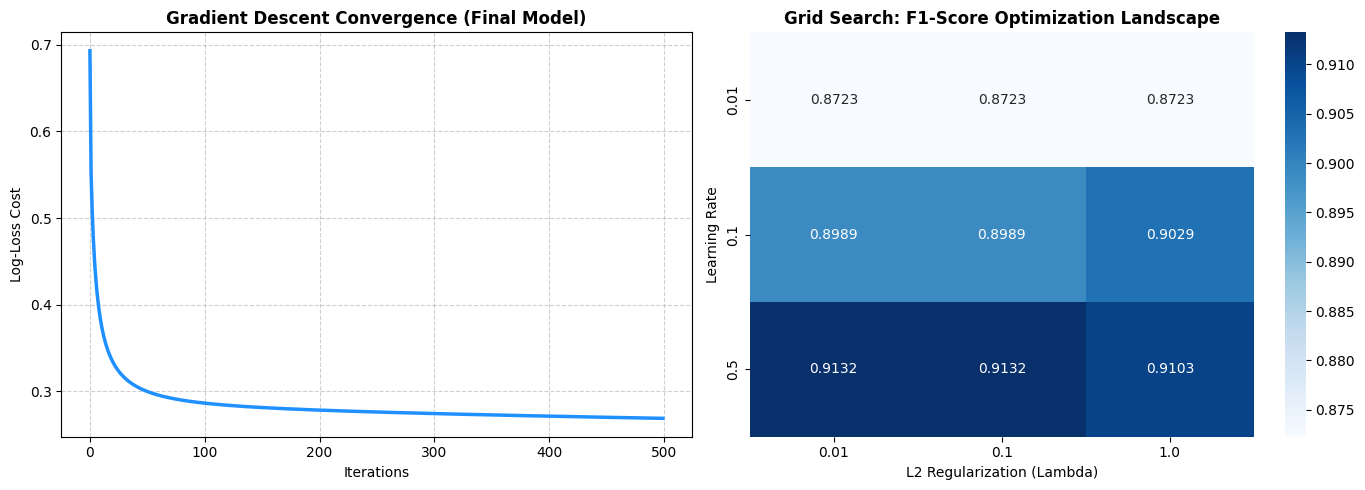

In [7]:
# 6. Loss Convergence & Hyperparameter Landscape Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost Reduction Curve
axes[0].plot(final_model.cost_history, color="dodgerblue", linewidth=2.5)
axes[0].set_title(
    "Gradient Descent Convergence (Final Model)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Log-Loss Cost")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: Grid Search Heatmap
f1_matrix = np.array(grid_f1_scores).reshape(
    len(learning_rates), len(lambda_params)
)
sns.heatmap(
    f1_matrix,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    xticklabels=lambda_params,
    yticklabels=learning_rates,
    ax=axes[1],
)
axes[1].set_title(
    "Grid Search: F1-Score Optimization Landscape",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("L2 Regularization (Lambda)")
axes[1].set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()